# LAB 03 - MACHINE LEARNING VỚI SCIKIT-LEARN
## House Prices: Advanced Regression Techniques (Ames Housing)

**Phụ trách:** NGUYỄN ĐÌNH CƯỜNG (Scikit-Learn Machine Learning)  
**Tài liệu tham khảo:** [Kế hoạch Lab 03](../../lab03_house_price_plan.md)  
**Tiền xử lý:** Nhận từ [`src/preprocessing.py`](../src/preprocessing.py) của MINH SANG.

---

### Mục tiêu của notebook này
1. **Tiếp nhận Pipeline tiền xử lý** từ MINH SANG và thiết lập luồng đánh giá không rò rỉ dữ liệu (No Data Leakage).
2. **Huấn luyện các mô hình Baseline:**
   - Tuyến tính: `DummyRegressor`, `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.
   - Cây & Ensemble: `DecisionTreeRegressor`, `RandomForestRegressor`, `ExtraTreesRegressor`, `GradientBoostingRegressor`, `HistGradientBoostingRegressor`.
3. **Đánh giá thống nhất:** 5-Fold Cross-Validation với metric RMSE trên target $\log(1 + \text{SalePrice})$.
4. **Tinh chỉnh siêu tham số (Hyperparameter Tuning):** Dùng `GridSearchCV` cho Ridge, Random Forest và Gradient Boosting.
5. **So sánh & Trực quan hoá:**
   - Biểu đồ so sánh RMSE giữa các mô hình.
   - Biểu đồ Residuals và tương quan Thực tế vs Dự đoán của mô hình tốt nhất.
6. **Bàn giao kết quả:** Lưu best model vào `models/best_sklearn_model.joblib` và bảng điểm vào `outputs/results/sklearn_results.csv`.

## 1. Thiết lập môi trường và nạp dữ liệu

In [1]:
import sys
from pathlib import Path

# Đảm bảo đường dẫn gốc project nằm trong sys.path để import src
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline

from src.preprocessing import (
    load_data,
    add_target_log,
    split_feature_target,
    select_column_groups,
    build_preprocessor,
    RANDOM_STATE,
)

# Cấu hình thẩm mỹ biểu đồ
plt.style.use("default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline

print("Tất cả thư viện và module tiền xử lý đã nạp thành công!")

Tất cả thư viện và module tiền xử lý đã nạp thành công!


## 2. Nạp dữ liệu và kiểm tra cấu trúc đặc trưng

In [2]:
# Nạp tập train từ data/
train_df, test_df = load_data()
train_df = add_target_log(train_df)

# Tách đặc trưng X và nhãn y (log1p SalePrice)
X, y = split_feature_target(train_df, drop_id=True)
numeric_cols, categorical_cols = select_column_groups(X)

print(f"Kích thước tập huấn luyện X: {X.shape}")
print(f"Kích thước nhãn y: {y.shape}")
print(f"Số lượng đặc trưng dạng số (numeric): {len(numeric_cols)}")
print(f"Số lượng đặc trưng phân loại (categorical): {len(categorical_cols)}")


Kích thước tập huấn luyện X: (1460, 79)
Kích thước nhãn y: (1460,)
Số lượng đặc trưng dạng số (numeric): 36
Số lượng đặc trưng phân loại (categorical): 43


## 3. Thiết lập Cross-Validation & Cơ chế chống rò rỉ dữ liệu (No Data Leakage)

Theo quy định mục 16 của Plan:
- Sử dụng **5-Fold Cross Validation** với `shuffle=True` và `random_state=42`.
- `build_preprocessor` được đặt bên trong `Pipeline` của scikit-learn để việc chuẩn hóa (`StandardScaler`), điền khuyết (`SimpleImputer`) và mã hóa (`OneHotEncoder`) được thực hiện độc lập trên từng fold train.

In [3]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_model_pipeline(regressor, scale_numeric=True, dense=False):
    """Đóng gói preprocessor và mô hình vào cùng một Pipeline."""
    sparse_thresh = 0.0 if dense else 0.3
    preprocessor = build_preprocessor(
        numeric_cols,
        categorical_cols,
        scale_numeric=scale_numeric,
        sparse_threshold=sparse_thresh,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])

def evaluate_model(name, pipeline, X, y, cv=cv):
    """Đánh giá mô hình bằng 5-fold CV với metric RMSE trên log1p(SalePrice)."""
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    rmse_scores = -scores
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    return {
        "model": name,
        "cv_rmse_mean": mean_rmse,
        "cv_rmse_std": std_rmse,
        "scores": rmse_scores,
    }


## 4. Huấn luyện các mô hình Baseline

Chúng ta sẽ đánh giá các mô hình cơ bản với tham số được thiết lập rõ ràng:
1. **DummyRegressor:** Dự đoán giá trị trung bình làm ngưỡng mốc cơ sở (baseline tối thiểu).
2. **LinearRegression:** Hồi quy OLS chuẩn.
3. **Ridge:** Hồi quy tuyến tính có điều chuẩn L2 (`alpha=10.0`).
4. **Lasso & ElasticNet:** Hồi quy tuyến tính có điều chuẩn L1 và kết hợp L1/L2.
5. **DecisionTreeRegressor:** Cây quyết định đơn lẻ.
6. **RandomForestRegressor & ExtraTreesRegressor:** Các mô hình Bagging ensemble.
7. **GradientBoostingRegressor & HistGradientBoostingRegressor:** Các mô hình Boosting ensemble.

In [4]:
baseline_definitions = [
    ("DummyRegressor", DummyRegressor(strategy="mean"), False, False, {"strategy": "mean"}),
    ("LinearRegression", LinearRegression(), True, False, {"fit_intercept": True}),
    ("Ridge", Ridge(alpha=10.0, random_state=RANDOM_STATE), True, False, {"alpha": 10.0}),
    ("Lasso", Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000), True, False, {"alpha": 0.001, "max_iter": 5000}),
    ("ElasticNet", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000), True, False, {"alpha": 0.001, "l1_ratio": 0.5, "max_iter": 5000}),
    ("DecisionTree", DecisionTreeRegressor(random_state=RANDOM_STATE), False, False, {"criterion": "squared_error"}),
    ("RandomForest", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), False, False, {"n_estimators": 100}),
    ("ExtraTrees", ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), False, False, {"n_estimators": 100}),
    ("GradientBoosting", GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE), False, False, {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3}),
    ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=RANDOM_STATE), False, True, {"max_iter": 100}),
]

baseline_results = []
baseline_pipelines = {}
baseline_params = {}

for name, reg, scale_num, is_dense, params in baseline_definitions:
    pipe = make_model_pipeline(reg, scale_numeric=scale_num, dense=is_dense)
    res = evaluate_model(name, pipe, X, y)
    baseline_results.append(res)
    baseline_pipelines[name] = pipe
    baseline_params[name] = params
    print(f"{name:22s} | 5-Fold CV RMSE: {res['cv_rmse_mean']:.5f} (+/- {res['cv_rmse_std']:.5f})")


DummyRegressor         | 5-Fold CV RMSE: 0.39878 (+/- 0.02513)


LinearRegression       | 5-Fold CV RMSE: 0.15274 (+/- 0.04702)


Ridge                  | 5-Fold CV RMSE: 0.14678 (+/- 0.03933)
Lasso                  | 5-Fold CV RMSE: 0.14428 (+/- 0.04247)


ElasticNet             | 5-Fold CV RMSE: 0.14285 (+/- 0.04202)


DecisionTree           | 5-Fold CV RMSE: 0.20913 (+/- 0.01846)


RandomForest           | 5-Fold CV RMSE: 0.14523 (+/- 0.01921)


ExtraTrees             | 5-Fold CV RMSE: 0.14388 (+/- 0.01170)


GradientBoosting       | 5-Fold CV RMSE: 0.13361 (+/- 0.01960)


HistGradientBoosting   | 5-Fold CV RMSE: 0.13530 (+/- 0.01828)


### 4.1. Bảng so sánh các mô hình Baseline

In [5]:
df_baseline = pd.DataFrame([
    {
        "model": r["model"],
        "cv_rmse_mean": round(r["cv_rmse_mean"], 5),
        "cv_rmse_std": round(r["cv_rmse_std"], 5),
        "status": "Baseline",
        "best_params": json.dumps(baseline_params[r["model"]]),
    }
    for r in baseline_results
]).sort_values("cv_rmse_mean", ascending=True).reset_index(drop=True)

df_baseline


,model,cv_rmse_mean,cv_rmse_std,status,best_params
0,GradientBoosting,0.13361,0.01960,Baseline,"{""n_estimators"": 100, ""learning_rate"": 0.1, ""m..."
1,HistGradientBoosting,0.13530,0.01828,Baseline,"{""max_iter"": 100}"
2,ElasticNet,0.14285,0.04202,Baseline,"{""alpha"": 0.001, ""l1_ratio"": 0.5, ""max_iter"": ..."
3,ExtraTrees,0.14388,0.01170,Baseline,"{""n_estimators"": 100}"
4,Lasso,0.14428,0.04247,Baseline,"{""alpha"": 0.001, ""max_iter"": 5000}"
5,RandomForest,0.14523,0.01921,Baseline,"{""n_estimators"": 100}"
6,Ridge,0.14678,0.03933,Baseline,"{""alpha"": 10.0}"
7,LinearRegression,0.15274,0.04702,Baseline,"{""fit_intercept"": true}"
8,DecisionTree,0.20913,0.01846,Baseline,"{""criterion"": ""squared_error""}"
9,DummyRegressor,0.39878,0.02513,Baseline,"{""strategy"": ""mean""}"


## 5. Tinh chỉnh siêu tham số (Hyperparameter Tuning)

Để tối ưu hóa hiệu năng, chúng ta thực hiện `GridSearchCV` trên 3 mô hình đại diện tiêu biểu nhất:
1. **Ridge:** Khảo sát hệ số phạt điều chuẩn $\alpha \in [0.1, 100.0]$.
2. **Random Forest:** Khảo sát `n_estimators`, `max_depth`, `min_samples_split`, và `max_features`.
3. **Gradient Boosting:** Khảo sát `learning_rate`, `n_estimators`, `max_depth`, và `subsample`.

### 5.1. Tinh chỉnh Ridge Regression

In [6]:
pipe_ridge = make_model_pipeline(Ridge(random_state=RANDOM_STATE), scale_numeric=True)

param_grid_ridge = {
    "regressor__alpha": [0.1, 0.5, 1.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0, 100.0]
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)
grid_ridge.fit(X, y)

best_ridge_rmse = -grid_ridge.best_score_
best_ridge_params = grid_ridge.best_params_
print(f"Best Ridge CV RMSE: {best_ridge_rmse:.5f}")
print("Best parameters:", best_ridge_params)


Best Ridge CV RMSE: 0.14655
Best parameters: {'regressor__alpha': 30.0}


### 5.2. Tinh chỉnh Random Forest Regressor

In [7]:
pipe_rf = make_model_pipeline(RandomForestRegressor(random_state=RANDOM_STATE), scale_numeric=False)

param_grid_rf = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 15, 25],
    "regressor__min_samples_split": [2, 5],
    "regressor__max_features": ["sqrt", 0.5, 1.0],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)
grid_rf.fit(X, y)

best_rf_rmse = -grid_rf.best_score_
best_rf_params = grid_rf.best_params_
print(f"Best Random Forest CV RMSE: {best_rf_rmse:.5f}")
print("Best parameters:", best_rf_params)


Best Random Forest CV RMSE: 0.13977
Best parameters: {'regressor__max_depth': None, 'regressor__max_features': 0.5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}


### 5.3. Tinh chỉnh Gradient Boosting Regressor

In [8]:
pipe_gb = make_model_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE), scale_numeric=False)

param_grid_gb = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 1.0],
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid=param_grid_gb,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)
grid_gb.fit(X, y)

best_gb_rmse = -grid_gb.best_score_
best_gb_params = grid_gb.best_params_
print(f"Best Gradient Boosting CV RMSE: {best_gb_rmse:.5f}")
print("Best parameters:", best_gb_params)


Best Gradient Boosting CV RMSE: 0.12915
Best parameters: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 300, 'regressor__subsample': 0.8}


## 6. Tổng hợp kết quả và Trực quan hoá so sánh

Lập bảng so sánh thống nhất giữa các mô hình Baseline và các mô hình đã được Tuning.

In [9]:
tuned_entries = [
    {
        "model": "Ridge (Tuned)",
        "cv_rmse_mean": round(best_ridge_rmse, 5),
        "cv_rmse_std": round(float(grid_ridge.cv_results_["std_test_score"][grid_ridge.best_index_]), 5),
        "status": "Tuned",
        "best_params": json.dumps(best_ridge_params),
    },
    {
        "model": "RandomForest (Tuned)",
        "cv_rmse_mean": round(best_rf_rmse, 5),
        "cv_rmse_std": round(float(grid_rf.cv_results_["std_test_score"][grid_rf.best_index_]), 5),
        "status": "Tuned",
        "best_params": json.dumps(best_rf_params),
    },
    {
        "model": "GradientBoosting (Tuned)",
        "cv_rmse_mean": round(best_gb_rmse, 5),
        "cv_rmse_std": round(float(grid_gb.cv_results_["std_test_score"][grid_gb.best_index_]), 5),
        "status": "Tuned",
        "best_params": json.dumps(best_gb_params),
    },
]

tuned_pipelines = {
    "Ridge (Tuned)": grid_ridge.best_estimator_,
    "RandomForest (Tuned)": grid_rf.best_estimator_,
    "GradientBoosting (Tuned)": grid_gb.best_estimator_,
}
tuned_params_dict = {
    "Ridge (Tuned)": best_ridge_params,
    "RandomForest (Tuned)": best_rf_params,
    "GradientBoosting (Tuned)": best_gb_params,
}

df_all_models = pd.concat([df_baseline, pd.DataFrame(tuned_entries)], ignore_index=True)
df_all_models = df_all_models.sort_values("cv_rmse_mean", ascending=True).reset_index(drop=True)

# [P1 Fix] Tra cứu chính xác estimator và parameters từ candidate dictionary
candidate_pipelines = {**baseline_pipelines, **tuned_pipelines}
candidate_params = {**baseline_params, **tuned_params_dict}

best_model_name = df_all_models.iloc[0]["model"]
best_pipeline = candidate_pipelines[best_model_name]
best_params = candidate_params[best_model_name]

print(f"Mô hình đạt kết quả tốt nhất: {best_model_name} với CV RMSE = {df_all_models.iloc[0]['cv_rmse_mean']:.5f}")
df_all_models


Mô hình đạt kết quả tốt nhất: GradientBoosting (Tuned) với CV RMSE = 0.12915


,model,cv_rmse_mean,cv_rmse_std,status,best_params
0,GradientBoosting (Tuned),0.12915,0.02309,Tuned,"{""regressor__learning_rate"": 0.05, ""regressor_..."
1,GradientBoosting,0.13361,0.01960,Baseline,"{""n_estimators"": 100, ""learning_rate"": 0.1, ""m..."
2,HistGradientBoosting,0.13530,0.01828,Baseline,"{""max_iter"": 100}"
3,RandomForest (Tuned),0.13977,0.01725,Tuned,"{""regressor__max_depth"": null, ""regressor__max..."
4,ElasticNet,0.14285,0.04202,Baseline,"{""alpha"": 0.001, ""l1_ratio"": 0.5, ""max_iter"": ..."
5,ExtraTrees,0.14388,0.01170,Baseline,"{""n_estimators"": 100}"
6,Lasso,0.14428,0.04247,Baseline,"{""alpha"": 0.001, ""max_iter"": 5000}"
7,RandomForest,0.14523,0.01921,Baseline,"{""n_estimators"": 100}"
8,Ridge (Tuned),0.14655,0.03997,Tuned,"{""regressor__alpha"": 30.0}"
9,Ridge,0.14678,0.03933,Baseline,"{""alpha"": 10.0}"


### 6.1. Biểu đồ xếp hạng hiệu năng (RMSE càng thấp càng tốt)

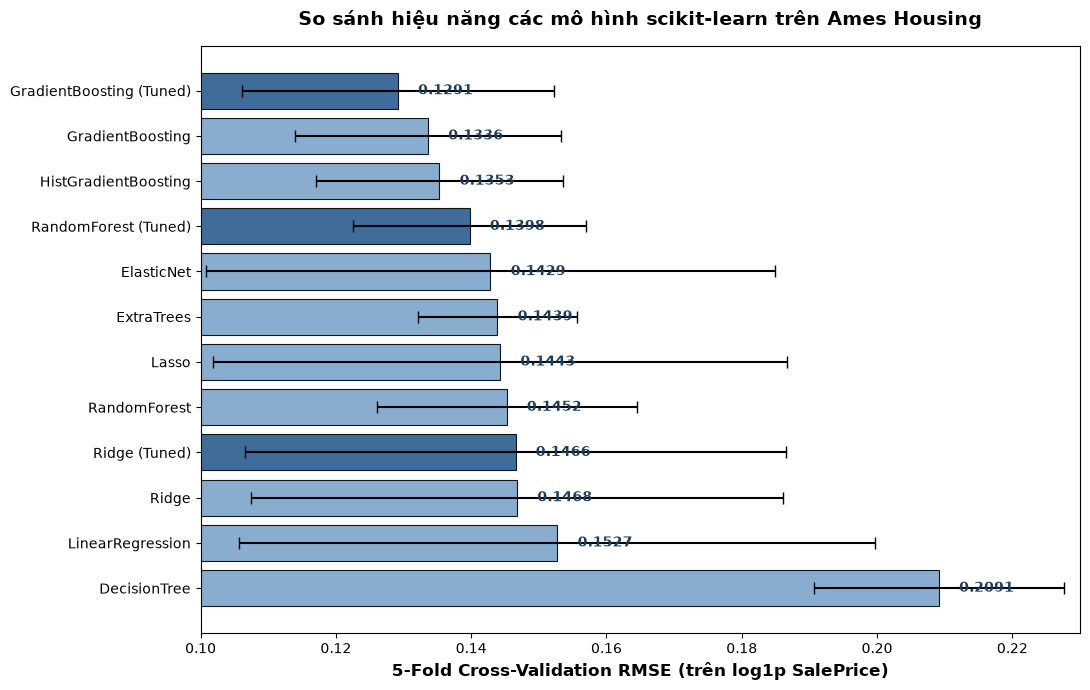

Đã lưu biểu đồ so sánh vào: E:\năm 4\kì 1\HỌC SÂU\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\figures\sklearn_models_comparison.png


In [10]:
# Vẽ biểu đồ so sánh CV RMSE của tất cả các mô hình
fig, ax = plt.subplots(figsize=(11, 7))

# Bỏ DummyRegressor để biểu đồ hiển thị chi tiết các mô hình cạnh tranh
plot_df = df_all_models[df_all_models["model"] != "DummyRegressor"].copy()
plot_df = plot_df.sort_values("cv_rmse_mean", ascending=False)

colors = ["#2b5c8f" if "Tuned" in s else "#7ba4c9" for s in plot_df["status"]]

bars = ax.barh(plot_df["model"], plot_df["cv_rmse_mean"], xerr=plot_df["cv_rmse_std"],
               color=colors, capsize=4, edgecolor="black", linewidth=0.8, alpha=0.9)

ax.set_xlabel("5-Fold Cross-Validation RMSE (trên log1p SalePrice)", fontsize=12, fontweight="bold")
ax.set_title("So sánh hiệu năng các mô hình scikit-learn trên Ames Housing", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0.10, 0.23)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.003, bar.get_y() + bar.get_height()/2, f"{width:.4f}",
            va="center", ha="left", fontsize=10, fontweight="bold", color="#1c3d5a")

plt.tight_layout()

# Lưu biểu đồ
fig_dir = project_root / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / "sklearn_models_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Đã lưu biểu đồ so sánh vào: {fig_path}")


### 6.2. Phân tích Residuals và Tương quan Thực tế vs Dự đoán của Best Model

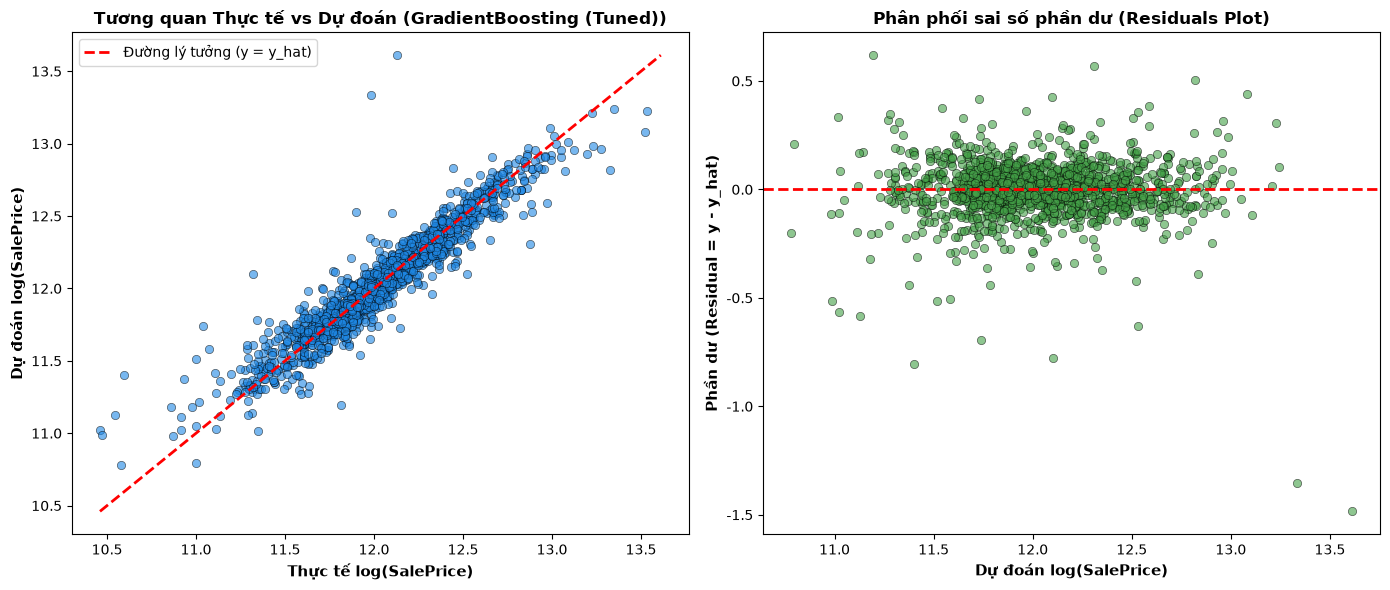

Đã lưu biểu đồ Residuals vào: E:\năm 4\kì 1\HỌC SÂU\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\figures\sklearn_best_model_residuals.png


In [11]:
# Sử dụng Best Pipeline được chọn động từ candidate_pipelines để lấy dự đoán Out-of-Fold
oof_preds = cross_val_predict(best_pipeline, X, y, cv=cv, n_jobs=-1)

residuals = y - oof_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Đồ thị 1: Actual vs Predicted
ax1.scatter(y, oof_preds, alpha=0.6, color="#1e88e5", edgecolors="k", linewidth=0.5)
min_val = min(y.min(), oof_preds.min())
max_val = max(y.max(), oof_preds.max())
ax1.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Đường lý tưởng (y = y_hat)")
ax1.set_xlabel("Thực tế log(SalePrice)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Dự đoán log(SalePrice)", fontsize=11, fontweight="bold")
ax1.set_title(f"Tương quan Thực tế vs Dự đoán ({best_model_name})", fontsize=12, fontweight="bold")
ax1.legend()

# Đồ thị 2: Residuals vs Predicted
ax2.scatter(oof_preds, residuals, alpha=0.6, color="#43a047", edgecolors="k", linewidth=0.5)
ax2.axhline(0, color="r", linestyle="--", linewidth=2)
ax2.set_xlabel("Dự đoán log(SalePrice)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Phần dư (Residual = y - y_hat)", fontsize=11, fontweight="bold")
ax2.set_title("Phân phối sai số phần dư (Residuals Plot)", fontsize=12, fontweight="bold")

plt.tight_layout()
residuals_fig_path = fig_dir / "sklearn_best_model_residuals.png"
plt.savefig(residuals_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Đã lưu biểu đồ Residuals vào: {residuals_fig_path}")


## 7. Bàn giao kết quả và Lưu trữ mô hình

Lưu mô hình tốt nhất (`models/best_sklearn_model.joblib`), bảng kết quả (`outputs/results/sklearn_results.csv`), và file tóm tắt JSON (`outputs/results/sklearn_best_summary.json`) để phục vụ làm báo cáo và bàn giao cho Thành viên 4 kết hợp với Feature Engineering.

In [12]:
# 1. Lưu toàn bộ kết quả vào outputs/results/sklearn_results.csv
results_dir = project_root / "outputs" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

df_all_models.to_csv(results_dir / "sklearn_results.csv", index=False)
print("Đã lưu bảng kết quả: outputs/results/sklearn_results.csv")

# 2. Fit Best Model Pipeline trên toàn bộ tập train và lưu joblib
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

best_pipeline.fit(X, y)
best_model_path = models_dir / "best_sklearn_model.joblib"
joblib.dump(best_pipeline, best_model_path)
print(f"Đã lưu Best Pipeline ({best_model_name}) vào: {best_model_path}")

# 3. [P2 & P3 Fix] Lưu JSON tóm tắt đầy đủ, đồng bộ cùng model
summary_meta = {
    "best_model_name": str(best_model_name),
    "best_cv_rmse": float(df_all_models.iloc[0]["cv_rmse_mean"]),
    "best_cv_rmse_std": float(df_all_models.iloc[0]["cv_rmse_std"]),
    "best_params": best_params,
    "metric": "RMSE on log1p(SalePrice)",
    "cv": "5-Fold KFold(shuffle=True, random_state=42)",
}
meta_path = results_dir / "sklearn_best_summary.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(summary_meta, f, indent=2, ensure_ascii=False)
print(f"Đã lưu tóm tắt mô hình vào: {meta_path}")

# 4. Thông tin tóm tắt cho báo cáo
print("\n--- TỔNG KẾT BÀN GIAO THÀNH VIÊN 2 ---")
print(f"Mô hình đạt kết quả cao nhất: {best_model_name}")
print(f"CV RMSE: {df_all_models.iloc[0]['cv_rmse_mean']:.5f} (+/- {df_all_models.iloc[0]['cv_rmse_std']:.5f})")
print("Best Parameters:")
for k, v in best_params.items():
    print(f"  - {k}: {v}")


Đã lưu bảng kết quả: outputs/results/sklearn_results.csv


Đã lưu Best Pipeline (GradientBoosting (Tuned)) vào: E:\năm 4\kì 1\HỌC SÂU\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\models\best_sklearn_model.joblib
Đã lưu tóm tắt mô hình vào: E:\năm 4\kì 1\HỌC SÂU\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\results\sklearn_best_summary.json

--- TỔNG KẾT BÀN GIAO THÀNH VIÊN 2 ---
Mô hình đạt kết quả cao nhất: GradientBoosting (Tuned)
CV RMSE: 0.12915 (+/- 0.02309)
Best Parameters:
  - regressor__learning_rate: 0.05
  - regressor__max_depth: 3
  - regressor__n_estimators: 300
  - regressor__subsample: 0.8
